# Brief Workflow of Synthesizer
## 1) Create Galaxy components

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from synthesizer.particle import Galaxy, Stars, BlackHoles
from unyt import Myr, Msun, yr, Mpc, cm, K

In [91]:
# Create Galaxy and its components (as Particle objects)
N =100
ages = np.random.rand(N) * 100 * Myr
metallicities = np.random.rand(N) / 100
initial_masses = np.ones(N) * 1e6 * Msun

part_stars = Stars(
    initial_masses=initial_masses,
    ages=ages,
    metallicities=metallicities,
)

# Make artificial black holes
n = 4
masses = 10 ** np.random.uniform(low=6, high=8, size=n) * Msun
coordinates = np.random.normal(0, 1.5, (n, 3)) * Mpc
accretion_rates = 10 ** np.random.uniform(low=-2, high=1, size=n) * Msun / yr
metallicities = np.full(n, 0.01)
tau_v = 0.5 * np.ones(n)

# And get the black holes object
blackholes = BlackHoles(
    masses=masses,
    coordinates=coordinates,
    accretion_rates=accretion_rates,
    metallicities=metallicities,
    tau_v=tau_v,
    ionisation_parameter_nlr=0.01,
    hydrogen_density_nlr=1e4 * cm**-3,
    ionisation_parameter_blr=0.1,
    hydrogen_density_blr=1e10 * cm**-3,
)

# And create the galaxy
galaxy = Galaxy(
    stars=part_stars,
    black_holes=blackholes,
    redshift=1,
)

Display properties/parameters of the Stars

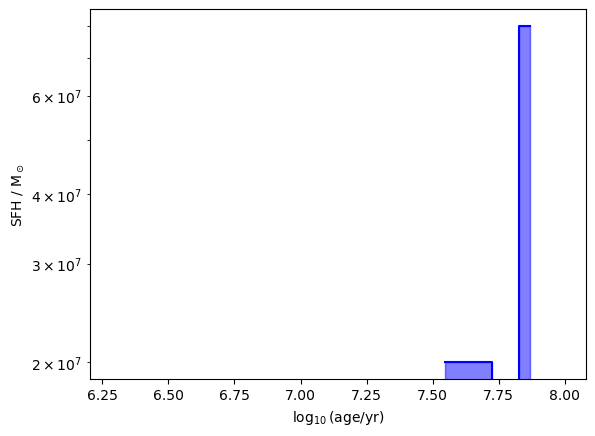

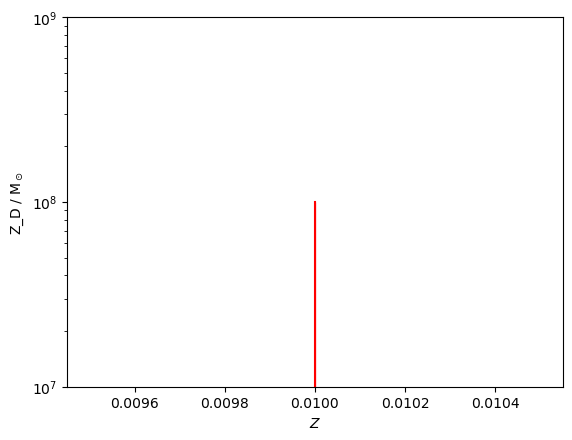

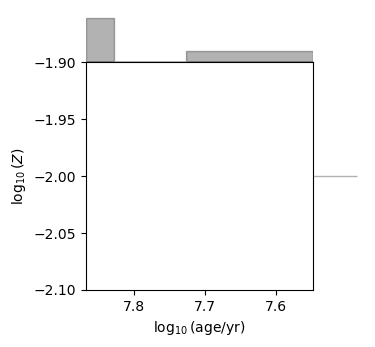

(<Figure size 350x350 with 3 Axes>,
 <Axes: xlabel='$\\log_{10}(\\mathrm{age}/\\mathrm{yr})$', ylabel='$\\log_{10}(Z)$'>)

In [ ]:
part_stars.plot_sfh(log10ages= np.log10(ages))
part_stars.plot_metal_dist(metallicities=metallicities)
part_stars.get_sfzh(log10ages=np.log10(ages), metallicities=metallicities )
part_stars.plot_sfzh()

## 2) Create Emission Model
Combine multiple models into one Emission Model, as the Galaxy contains Stars and Black Holes.

It is optional to display the emission tree, allowing user to track the spectra and decide which one you want.

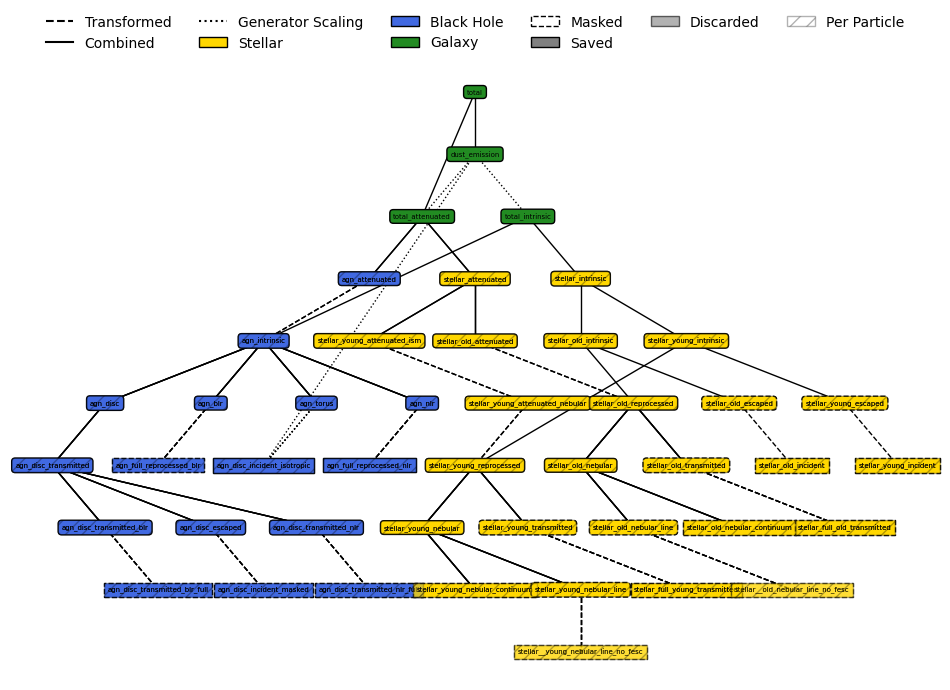

(<Figure size 1200x800 with 1 Axes>, <Axes: >)

In [104]:
from synthesizer.emission_models import (
    BimodalPacmanEmission,
    Blackbody,
    DustEmission,
    EmissionModel,
    Greybody,
    UnifiedAGN,
)
from synthesizer.emission_models.attenuation import PowerLaw
from synthesizer.grid import Grid
from synthesizer.particle import BlackHoles, Galaxy

# Get the grids which we'll need for extraction
grid_name = "test_grid"
grid = Grid(grid_name)
nlr_grid = Grid("test_grid_agn-nlr")
blr_grid = Grid("test_grid_agn-blr")

# Get the stellar pacman model
pc_model = BimodalPacmanEmission(
    grid=grid,
    tau_v_ism=1.0,
    tau_v_birth=0.7,
    dust_curve_ism=PowerLaw(slope=-1.3),
    dust_curve_birth=PowerLaw(slope=-0.7),
    dust_emission_ism=Blackbody(temperature=100 * K),
    dust_emission_birth=Blackbody(temperature=30 * K),
    fesc=0.2,
    fesc_ly_alpha=0.9,
    label="stellar_total",
)
pc_model.set_per_particle(True)

# Initialise the UnifiedAGN model
uniagn = UnifiedAGN(
    nlr_grid,
    blr_grid,
    ionisation_parameter_nlr=0.01,
    hydrogen_density_nlr=1e4 * cm**-3,
    ionisation_parameter_blr=0.1,
    hydrogen_density_blr=1e10 * cm**-3,
    torus_emission_model=Greybody(1000 * K, 1.5),
    diffuse_dust_curve=PowerLaw(slope=-1.0),
    per_particle=True,
)
uniagn.add_label_prefix("agn")
pc_model.add_label_prefix("stellar")


gal_intrinsic = EmissionModel(
    label="total_intrinsic",
    combine=(uniagn["agn_intrinsic"], pc_model["stellar_intrinsic"]),
    emitter="galaxy",
)

gal_attenuated = EmissionModel(
    label="total_attenuated",
    combine=(uniagn["agn_attenuated"], pc_model["stellar_attenuated"]),
    related_models=(gal_intrinsic,),
    emitter="galaxy",
)

# And now include the dust emission
gal_dust = DustEmission(
    dust_emission_model=Greybody(30 * K, 1.2),
    dust_lum_intrinsic=gal_intrinsic,
    dust_lum_attenuated=gal_attenuated,
    emitter="galaxy",
    label="dust_emission",
)

gal_total_EmissionModel = EmissionModel(
    label="total",
    combine=(gal_attenuated, gal_dust),
    related_models=(gal_intrinsic,),
    emitter="galaxy",
)

# Optional: Display an emission tree
gal_total_EmissionModel.plot_emission_tree(fontsize=5, figsize=(12, 8), show=True)

We save only those spectra we want

In [97]:
gal_total_EmissionModel.save_spectra(
    "total",
    "dust_emission",
    "total_attenuated",
    "total_intrinsic",
    "stellar_intrinsic",
    "stellar_attenuated",
)

## 3) Create Galaxy object 
It includes Stars and BlackHoles in this example.

In [ ]:
# Set parameters for Stars
N = 20
ages = np.random.rand(N) * 100 * Myr
metallicities = np.random.rand(N) / 100
initial_masses = np.ones(N) * 1e6 * Msun
# Create the Stars object
part_stars = Stars(
    initial_masses=initial_masses,
    ages=ages,
    metallicities=metallicities,
)

# Set parameters for Black Holes
n = 4
masses = 10 ** np.random.uniform(low=6, high=8, size=n) * Msun
coordinates = np.random.normal(0, 1.5, (n, 3)) * Mpc
accretion_rates = 10 ** np.random.uniform(low=-2, high=1, size=n) * Msun / yr
metallicities = np.full(n, 0.01)
tau_v = 0.5 * np.ones(n)
# Create the Black Holes object
blackholes = BlackHoles(
    masses=masses,
    coordinates=coordinates,
    accretion_rates=accretion_rates,
    metallicities=metallicities,
    tau_v=tau_v,
    ionisation_parameter_nlr=0.01,
    hydrogen_density_nlr=1e4 * cm**-3,
    ionisation_parameter_blr=0.1,
    hydrogen_density_blr=1e10 * cm**-3,
)

# Create the galaxy
galaxy = Galaxy(
    stars=part_stars,
    black_holes=blackholes,
    redshift=1,
)

## Apply the EmissionModel to the Galaxy object
To generate a SED, by applying the total Emission Model to the Galaxy object.

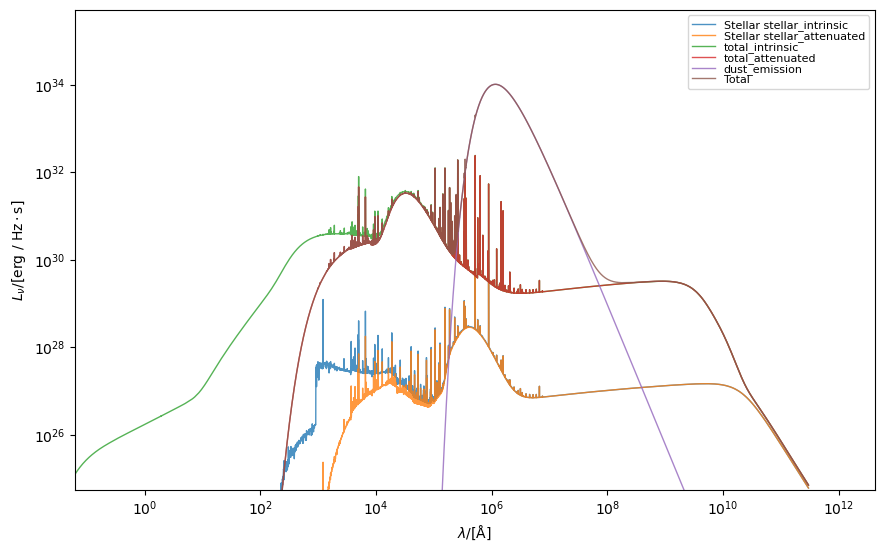

(<Figure size 1000x800 with 1 Axes>,
 <Axes: xlabel='$\\lambda/[\\mathrm{\\AA}]$', ylabel='$L_{\\nu}/[\\mathrm{\\rm{erg} \\ / \\ \\rm{Hz \\cdot \\rm{s}}}]$'>)

In [100]:
sed = galaxy.get_spectra(gal_total_EmissionModel)
galaxy.plot_spectra(
    combined_spectra=True,
    stellar_spectra=True,
    black_hole_spectra=False,
    show=True,
    figsize=(10, 8),
)

## Applying attenuation.
We apply an artificial attenuation on the SED, and display the original SED and attenuated one.

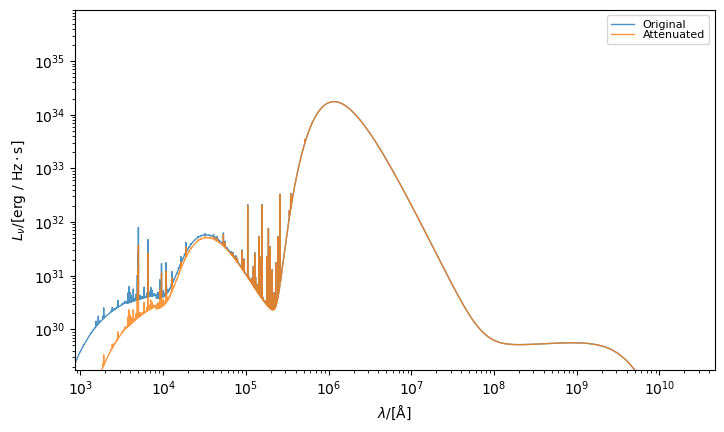

In [ ]:
from synthesizer.emission_models.attenuation import PowerLaw

sed_att = sed.apply_attenuation(tau_v=0.7, dust_curve=PowerLaw(-1.0))

# Integrate the constituent spectra in the SED object
int_sed = sed.sum()
int_sed_att = sed_att.sum()

fig, ax = int_sed.plot_spectra(label="Original", figsize=(8,6))
fig, ax = int_sed_att.plot_spectra(label="Attenuated", fig=fig, ax=ax)


(<Figure size 500x50 with 1 Axes>, <Axes: xlabel='$\\lambda/\\AA$'>)

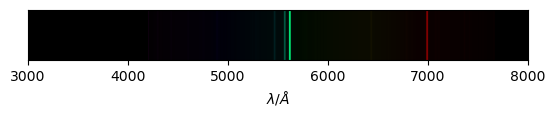

In [ ]:
sed.plot_spectra_as_rainbow()